In [5]:
#Homework2 Jiayan Wang

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Km = 15.0000 nM
Vmax = 0.5000 nM/min

完整机理模型最终 P = 75.224904 nM
Michaelis-Menten 模型最终 P = 77.575056 nM
最终差值 = -2.350152 nM
最大绝对差值 = 2.350152 nM


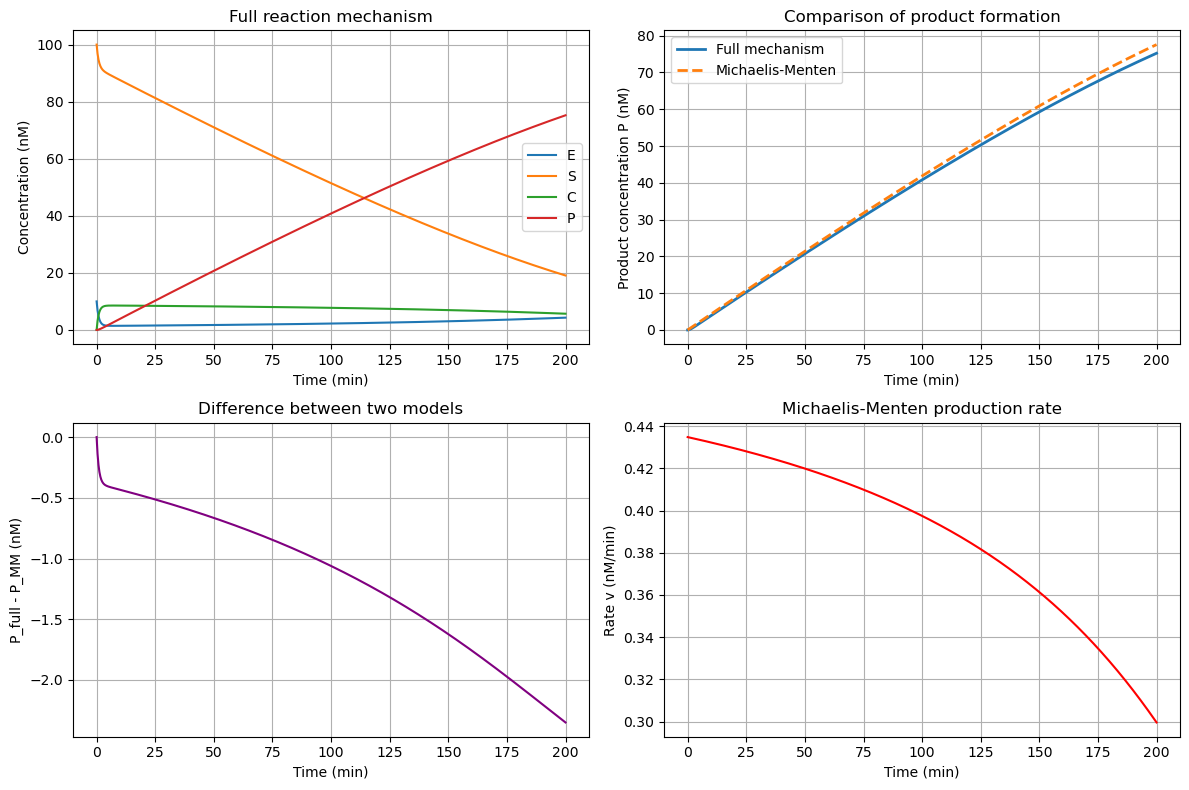

In [2]:
# 1. 参数设置
# ============================================================

# 反应速率常数
# k1: nM^-1 min^-1
# k_minus1, k2: min^-1
k1 = 0.01
k_minus1 = 0.1
k2 = 0.05

# 初始浓度
E0 = 10.0       # 初始酶浓度，nM
S0 = 100.0      # 初始底物浓度，nM
C0 = 0.0        # 初始复合物浓度，nM
P0 = 0.0        # 初始产物浓度，nM

# 时间范围，单位 min
t_start = 0
t_end = 200
t_eval = np.linspace(t_start, t_end, 1000)


# ============================================================
# 2. 根据完整反应机理建立 ODE
# ============================================================

def full_mechanism(t, y, k1, k_minus1, k2):
    """
    y[0] = E
    y[1] = S
    y[2] = C
    y[3] = P
    """

    E, S, C, P = y

    # 正向结合反应：E + S -> C
    forward_binding = k1 * E * S

    # 解离反应：C -> E + S
    reverse_binding = k_minus1 * C

    # 催化反应：C -> E + P
    catalysis = k2 * C

    dE_dt = -forward_binding + reverse_binding + catalysis
    dS_dt = -forward_binding + reverse_binding
    dC_dt = forward_binding - reverse_binding - catalysis
    dP_dt = catalysis

    return [dE_dt, dS_dt, dC_dt, dP_dt]


# 数值求解完整反应机理
solution_full = solve_ivp(
    fun=full_mechanism,
    t_span=(t_start, t_end),
    y0=[E0, S0, C0, P0],
    t_eval=t_eval,
    args=(k1, k_minus1, k2),
    rtol=1e-9,
    atol=1e-12
)

E_full = solution_full.y[0]
S_full = solution_full.y[1]
C_full = solution_full.y[2]
P_full = solution_full.y[3]


# ============================================================
# 3. 使用 Michaelis-Menten 公式计算 P
# ============================================================

# Michaelis 常数
Km = (k_minus1 + k2) / k1

# 最大反应速率
Vmax = k2 * E0

print(f"Km = {Km:.4f} nM")
print(f"Vmax = {Vmax:.4f} nM/min")


def michaelis_menten_model(t, y, Vmax, Km, S0):
    """
    y[0] = P

    因为 S + P = S0，
    所以当前底物浓度为 S = S0 - P
    """

    P = y[0]

    # 底物不能小于 0
    S = max(S0 - P, 0)

    # 第三张图中的 Michaelis-Menten 速率
    v = Vmax * S / (Km + S)

    # 产物生成速率
    dP_dt = v

    return [dP_dt]


# 数值积分 Michaelis-Menten 模型
solution_mm = solve_ivp(
    fun=michaelis_menten_model,
    t_span=(t_start, t_end),
    y0=[P0],
    t_eval=t_eval,
    args=(Vmax, Km, S0),
    rtol=1e-9,
    atol=1e-12
)

P_mm = solution_mm.y[0]

# 根据 MM 模型得到底物浓度和瞬时反应速率
S_mm = S0 - P_mm
v_mm = Vmax * S_mm / (Km + S_mm)


# ============================================================
# 4. 计算两种方法的差异
# ============================================================

difference = P_full - P_mm
absolute_difference = np.abs(difference)

max_difference = np.max(absolute_difference)
final_difference = difference[-1]

print()
print(f"完整机理模型最终 P = {P_full[-1]:.6f} nM")
print(f"Michaelis-Menten 模型最终 P = {P_mm[-1]:.6f} nM")
print(f"最终差值 = {final_difference:.6f} nM")
print(f"最大绝对差值 = {max_difference:.6f} nM")


# ============================================================
# 5. 绘图比较
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 图 1：完整机理中的所有组分
axes[0, 0].plot(t_eval, E_full, label="E")
axes[0, 0].plot(t_eval, S_full, label="S")
axes[0, 0].plot(t_eval, C_full, label="C")
axes[0, 0].plot(t_eval, P_full, label="P")

axes[0, 0].set_xlabel("Time (min)")
axes[0, 0].set_ylabel("Concentration (nM)")
axes[0, 0].set_title("Full reaction mechanism")
axes[0, 0].legend()
axes[0, 0].grid(True)

# 图 2：P 的产量比较
axes[0, 1].plot(
    t_eval,
    P_full,
    linewidth=2,
    label="Full mechanism"
)

axes[0, 1].plot(
    t_eval,
    P_mm,
    "--",
    linewidth=2,
    label="Michaelis-Menten"
)

axes[0, 1].set_xlabel("Time (min)")
axes[0, 1].set_ylabel("Product concentration P (nM)")
axes[0, 1].set_title("Comparison of product formation")
axes[0, 1].legend()
axes[0, 1].grid(True)

# 图 3：两个模型的差异
axes[1, 0].plot(t_eval, difference, color="purple")

axes[1, 0].set_xlabel("Time (min)")
axes[1, 0].set_ylabel("P_full - P_MM (nM)")
axes[1, 0].set_title("Difference between two models")
axes[1, 0].grid(True)

# 图 4：Michaelis-Menten 瞬时速率
axes[1, 1].plot(t_eval, v_mm, color="red")

axes[1, 1].set_xlabel("Time (min)")
axes[1, 1].set_ylabel("Rate v (nM/min)")
axes[1, 1].set_title("Michaelis-Menten production rate")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()